In [62]:
import MotifCompendium
mc = MotifCompendium.load("motif_compendium_chip_selex_annotated.mc", safe=True)
mcf = mc[mc['flag_remove']==False]
mct = mcf[(mcf["selex_score0"]>0.6) & (mcf["chipdb_score1"]>0.5)]

In [63]:
import pandas as pd
motif_table = pd.read_csv("/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/reviews/composite_moitfs_synergy_annotated_table.csv", sep=",", header=0)

In [64]:
syn_motifs = motif_table[motif_table["synergy"]]
unique_motif_table = syn_motifs.drop_duplicates(subset='cluster')


In [65]:
unique_motif_table.shape

(30, 37)

In [66]:
sum(unique_motif_table["hard_syntax"])

9

In [67]:
motif_names = unique_motif_table["name_x"].values

In [68]:
import h5py
import numpy as np

def load_dict_from_h5(h5group):
    dic = {}
    for key, item in h5group.items():
        if isinstance(item, h5py.Group):
            # If subgroup looks like a list (all keys are integers)
            if all(k.isdigit() for k in item.keys()):
                lst = [item[str(i)][()] for i in sorted(map(int, item.keys()))]
                dic[key] = lst
            else:
                dic[key] = load_dict_from_h5(item)
        elif isinstance(item, h5py.Dataset):
            dic[key] = item[()]
    return dic

# Function to load the whole dictionary from HDF5 file
def load_from_h5(filename):
    with h5py.File(filename, 'r') as h5file:
        return load_dict_from_h5(h5file)

h5file="/mnt/lab_data2/anusri/chrombpnet/src/evaluation/marginal_footprints/composite_footprint_data.h5"
loaded_data = load_from_h5(h5file)
h5file="/mnt/lab_data2/anusri/chrombpnet/src/evaluation/marginal_footprints/composite_footprint_data_rev.h5"
loaded_data_rev = load_from_h5(h5file)

In [69]:
# get distances and arrange them
distances = []
for i,r in motif_table.iterrows():
    #print(loaded_data[r["name_x"]]['combine_counts'].keys())
    for key in loaded_data[r["name_x"]]['combine_counts'].keys():
        distances.append(int(key))
    break
distances=sorted(distances)


In [70]:
#len(distances)

In [125]:
#distances[22:]
motif_table.columns

Index(['name_x', 'Annotation', 'motif1_strings_corrected',
       'motif2_strings_corrected', 'motif1_strings', 'motif2_strings',
       'num_seqlets', 'model', 'posneg', 'avg_contrib', 'avg_dist_from_summit',
       'cluster', 'selex_score0', 'selex_name0', 'chipdb_score0',
       'chipdb_name0', 'chipdb_score1', 'chipdb_name1', 'motif_entropy',
       'weighted_base_entropy', 'weighted_position_entropy',
       'posbase_entropy_score', 'copair_entropy_score', 'copair_composition',
       'dinuc_entropy_score', 'dinuc_composition', 'dinuc_score',
       'posneg_inverted', 'truncated', 'flag_remove', 'name_y', 'label',
       'motif1_locs', 'motif2_locs', 'cell_type', 'synergy', 'hard_syntax'],
      dtype='object')

In [94]:
values_per_motif = {}
from scipy.stats import
for keyd in motif_names:
    values = []
    values_rev = []

    values_per_motif[keyd] = []

    motifA = np.log(loaded_data[keyd]['motif1']['counts']) - np.log(loaded_data[keyd]['control']['counts'])
    motifB = np.log(loaded_data[keyd]['motif2']['counts']) - np.log(loaded_data[keyd]['control']['counts'])
    for dist in distances:
        values.append(np.log(loaded_data[keyd]['combine_counts'][str(dist)]) - np.log(loaded_data[keyd]['control']['counts']))

    rmotifA = np.log(loaded_data_rev[keyd]['motif1']['counts']) - np.log(loaded_data_rev[keyd]['control']['counts'])
    rmotifB = np.log(loaded_data_rev[keyd]['motif2']['counts']) - np.log(loaded_data_rev[keyd]['control']['counts'])
    for dist in distances:
        values_rev.append(np.log(loaded_data_rev[keyd]['combine_counts'][str(dist)]) - np.log(loaded_data_rev[keyd]['control']['counts']))

    

    values_per_motif[keyd] = [motifA+motifB, rmotifA+rmotifB, values[22:], values[0:22][::-1],  values_rev[22:], values_rev[0:22][::-1], values, values_rev]
    
    
    

In [95]:
#values_per_motif[keyd][2]
from IPython.display import Image, display
import base64
import matplotlib.pyplot as plt
from io import BytesIO
logo_fwd = mct.get_images('logo (fwd)')

In [96]:
hard_motifs = unique_motif_table[unique_motif_table["hard_syntax"]]["name_x"].values

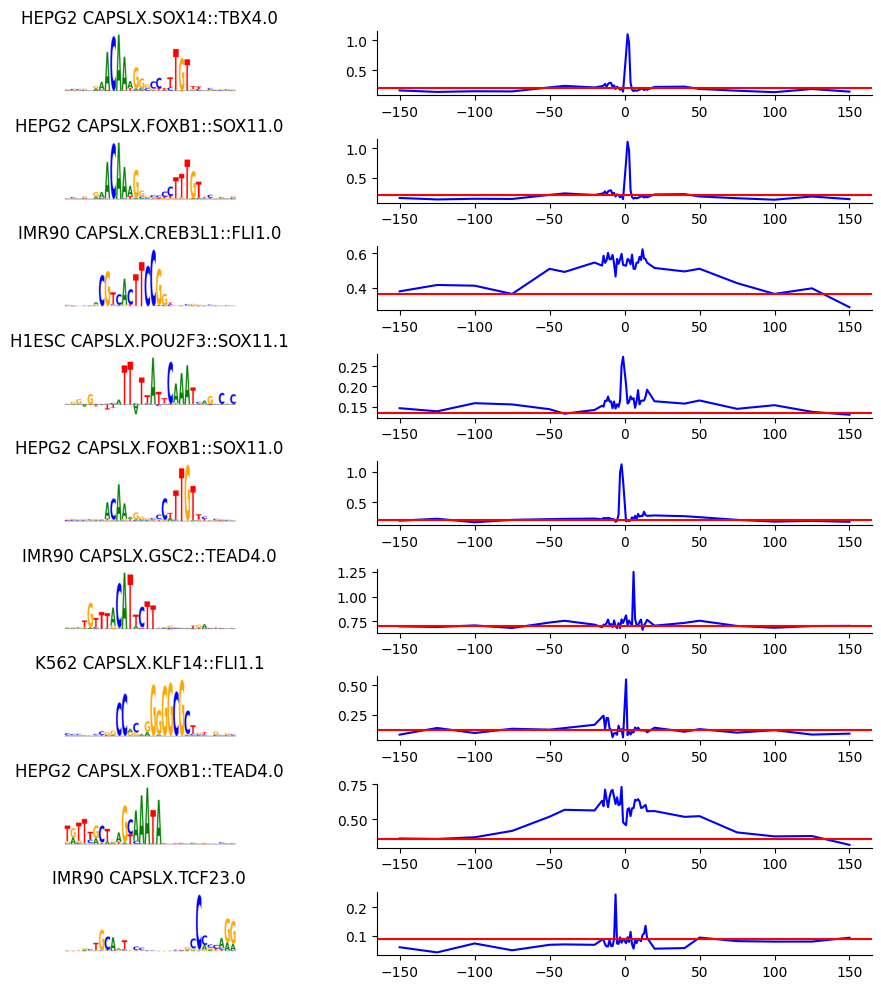

In [146]:
plot_motifs=hard_motifs
fig, ax = plt.subplots(len(plot_motifs), 2, figsize=(10, 10))
blue_shades = ['#0000FF', '#1E90FF', '#00BFFF', '#87CEFA', '#ADD8E6', '#B0E0E6']
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42 

idx=0
for keyd in plot_motifs:

    motif_table["label"].str.split("add", expand=True)
    
    index = mct.metadata[mct['name'] == keyd].index[0]
    image_bytes_1 = base64.b64decode(logo_fwd[index])
    ax[idx,0].imshow(plt.imread(BytesIO(image_bytes_1)))
    ax[idx,0].axis('off')  # Turn off axes for the motif logo
    ax[idx,0].set_title(motif_table[motif_table['name_x']==keyd]["cell_type"].values[0]+" "+motif_table[motif_table['name_x']==keyd]['selex_name0'].values[0])

     # Plot values in the second column
    ax[idx, 1].plot(distances, values_per_motif[keyd][6], c=blue_shades[0], label='values_per_motif[2]') # Plot line for points
    #ax[idx, 1].plot(distances, values_per_motif[keyd][3], c=blue_shades[3], label='values_per_motif[3]') # Plot line for points
    #ax[idx, 2].plot(distances[22:], values_per_motif[keyd][4], c='b', label='values_per_motif[4]') # Plot line for points
    #ax[idx, 2].plot(distances[22:], values_per_motif[keyd][5], c='b', label='values_per_motif[5]') # Plot line for points
    ax[idx, 1].axhline(values_per_motif[keyd][0], label='values_per_motif[0]', color='r') # Draw horizontal line
    #ax[idx, 2].axhline(values_per_motif[keyd][1], label='values_per_motif[1]', color='r') # Draw horizontal line
    
    # Adding legend to differentiate lines
    #ax[idx, 1].legend()
    ax[idx, 1].spines['top'].set_visible(False)
    ax[idx, 1].spines['right'].set_visible(False)

    # Increment index
    idx += 1

fig.tight_layout()
#plt.show()  
plt.savefig("/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/reviews/figures/hard_syntax_motifs.pdf", transparent=True, dpi=300)

In [132]:
soft_motifs = unique_motif_table[unique_motif_table["synergy"] & ~unique_motif_table["hard_syntax"]]["name_x"].values

In [133]:
#unique_motif_table

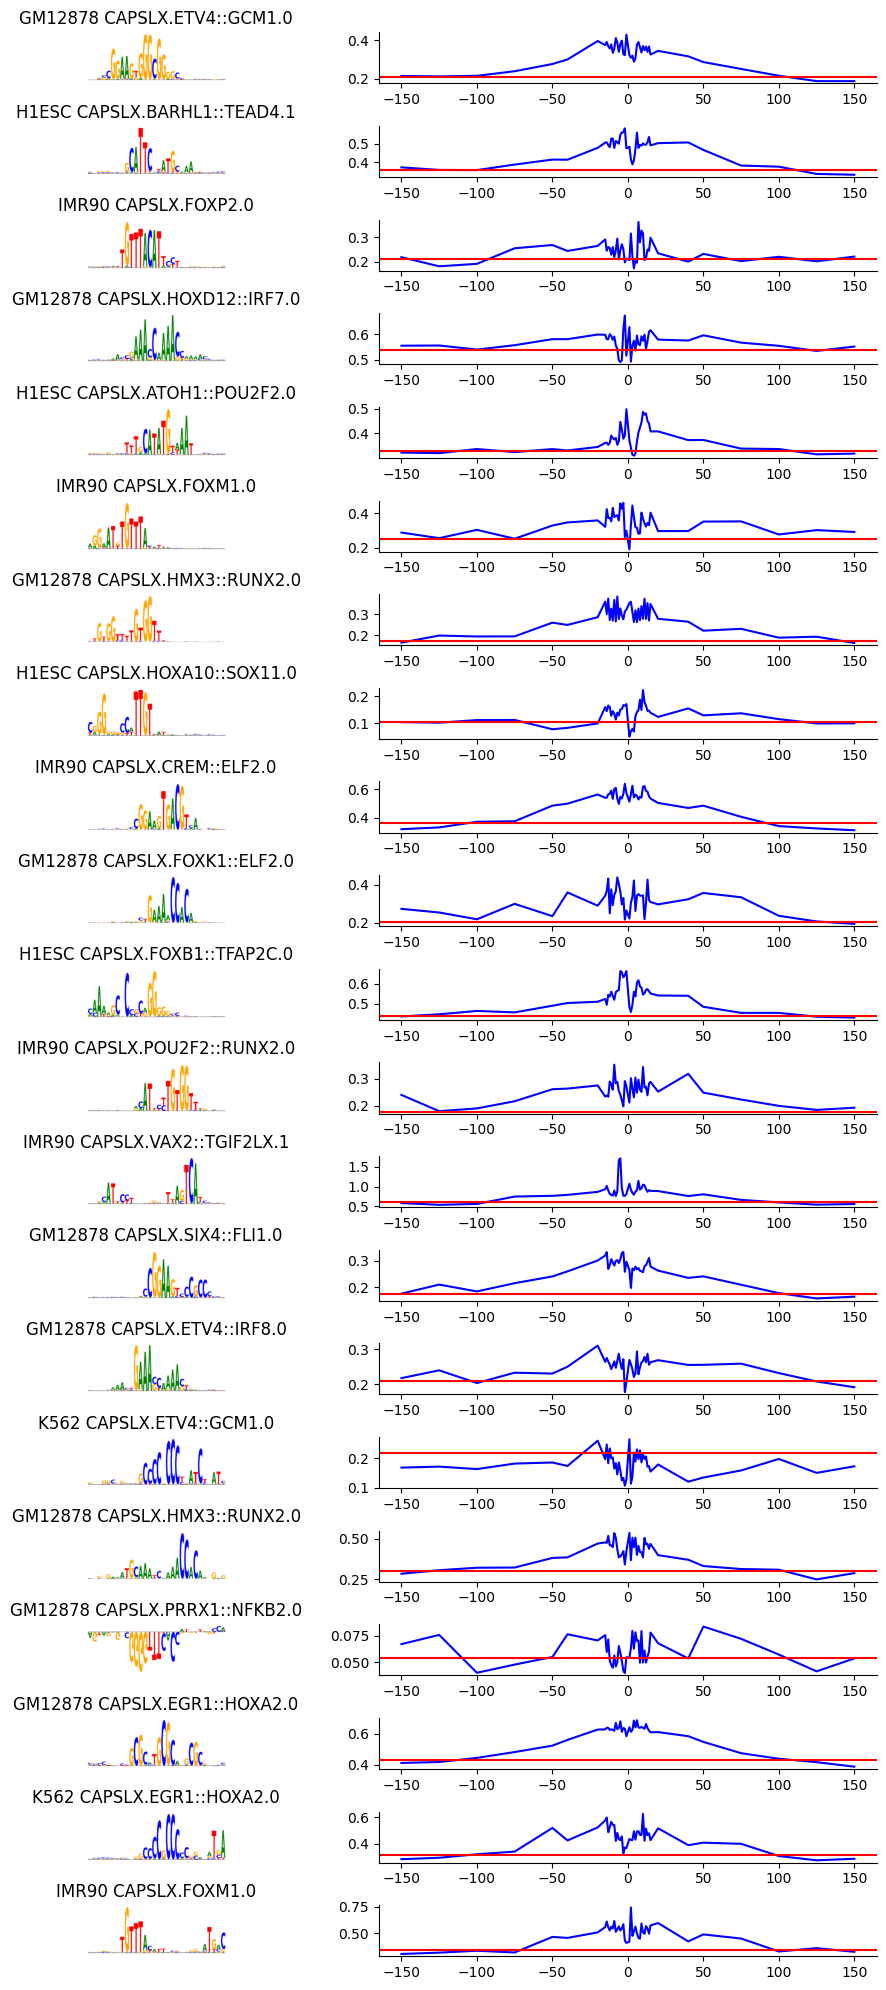

In [147]:
plot_motifs=soft_motifs
fig, ax = plt.subplots(len(plot_motifs), 2, figsize=(10, 20))
blue_shades = ['#0000FF', '#1E90FF', '#00BFFF', '#87CEFA', '#ADD8E6', '#B0E0E6']

idx=0
for keyd in plot_motifs:
    
    index = mct.metadata[mct['name'] == keyd].index[0]
    image_bytes_1 = base64.b64decode(logo_fwd[index])
    ax[idx,0].imshow(plt.imread(BytesIO(image_bytes_1)))
    ax[idx,0].axis('off')  # Turn off axes for the motif logo
    #print()
    ax[idx,0].set_title(motif_table[motif_table['name_x']==keyd]["cell_type"].values[0]+" "+motif_table[motif_table['name_x']==keyd]['selex_name0'].values[0])

     # Plot values in the second column
    ax[idx, 1].plot(distances, values_per_motif[keyd][6], c=blue_shades[0], label='values_per_motif[2]') # Plot line for points
    #ax[idx, 1].plot(distances[22:], values_per_motif[keyd][3], c=blue_shades[3], label='values_per_motif[3]') # Plot line for points
    #ax[idx, 2].plot(distances[22:], values_per_motif[keyd][4], c='b', label='values_per_motif[4]') # Plot line for points
    #ax[idx, 2].plot(distances[22:], values_per_motif[keyd][5], c='b', label='values_per_motif[5]') # Plot line for points
    ax[idx, 1].axhline(values_per_motif[keyd][0], label='values_per_motif[0]', color='r') # Draw horizontal line
    #ax[idx, 2].axhline(values_per_motif[keyd][1], label='values_per_motif[1]', color='r') # Draw horizontal line
    
    # Adding legend to differentiate lines
    #ax[idx, 1].legend()
    ax[idx, 1].spines['top'].set_visible(False)
    ax[idx, 1].spines['right'].set_visible(False)    
    # Increment index
    idx += 1


fig.tight_layout()
#plt.show()  
plt.savefig("/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/reviews/figures/soft_syntax_motifs.pdf", transparent=True, dpi=300)

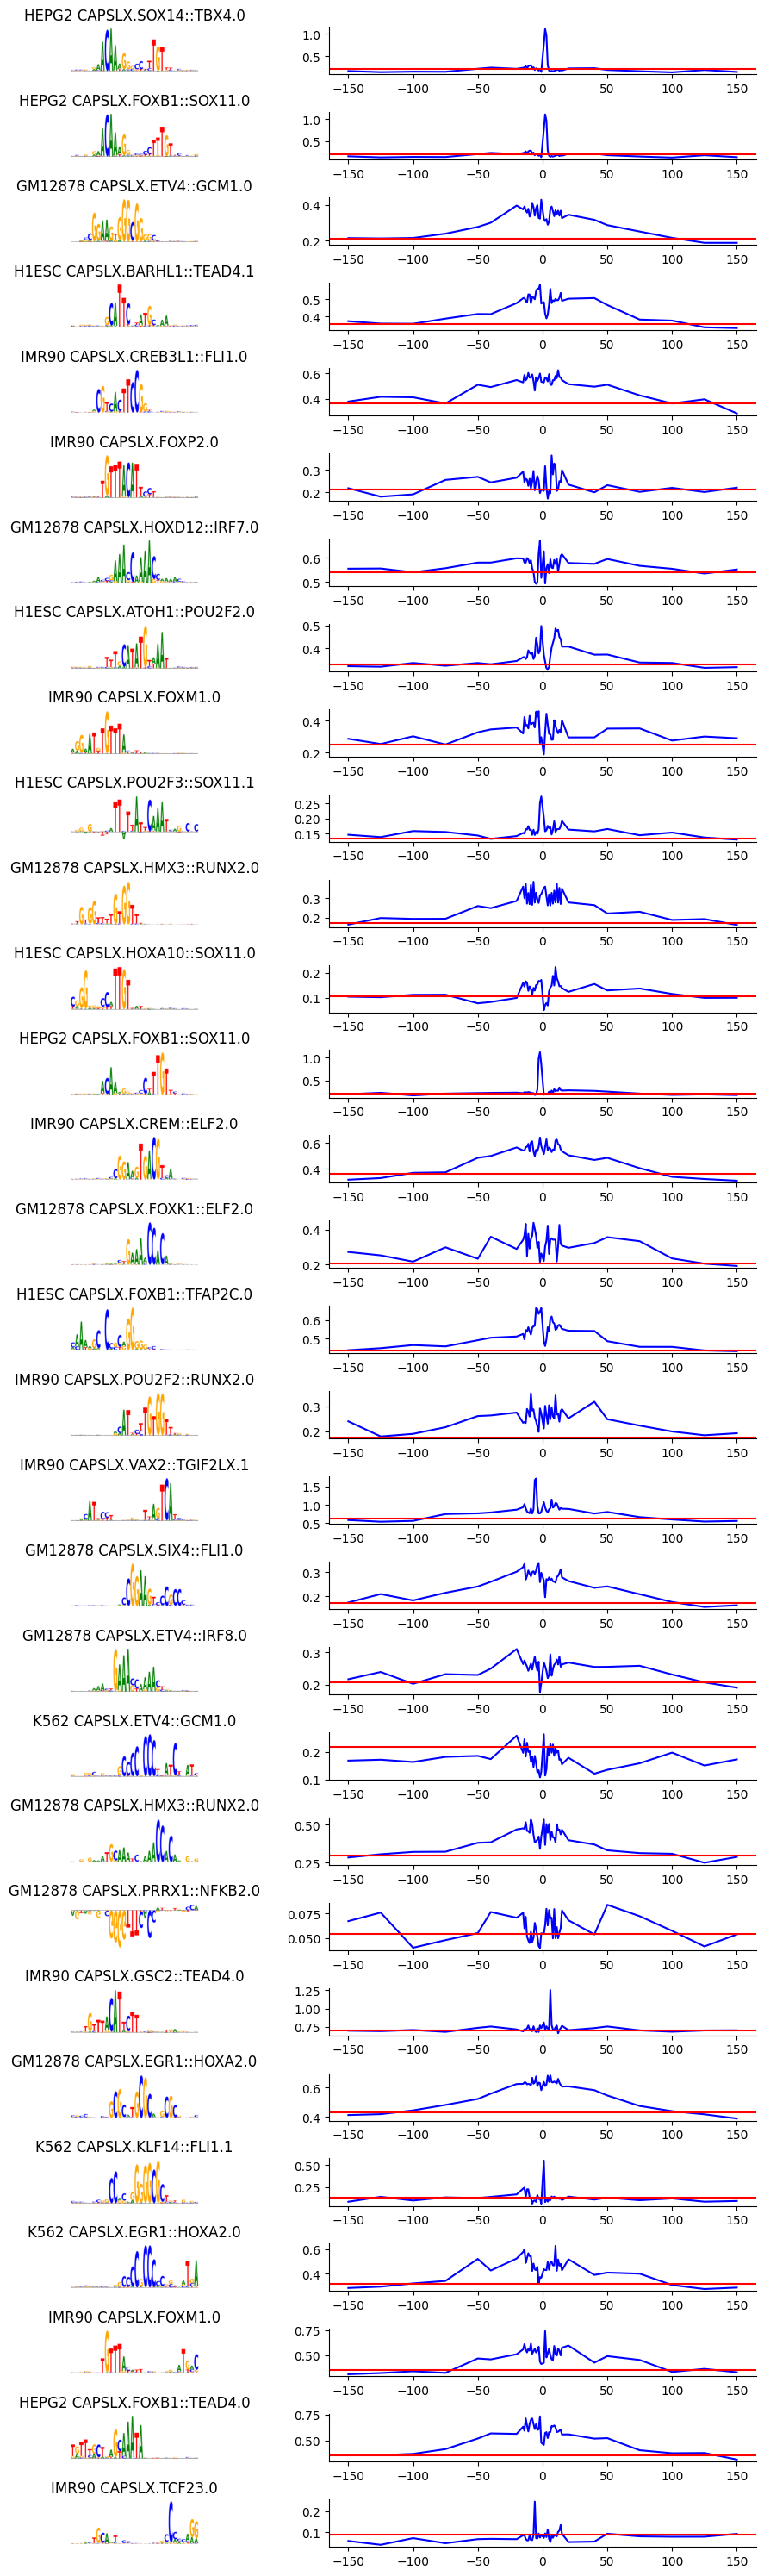

In [148]:
plot_motifs=motif_names
fig, ax = plt.subplots(len(plot_motifs), 2, figsize=(10, 30))
blue_shades = ['#0000FF', '#1E90FF', '#00BFFF', '#87CEFA', '#ADD8E6', '#B0E0E6']
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42 

idx=0
for keyd in plot_motifs:

    motif_table["label"].str.split("add", expand=True)
    
    index = mct.metadata[mct['name'] == keyd].index[0]
    image_bytes_1 = base64.b64decode(logo_fwd[index])
    ax[idx,0].imshow(plt.imread(BytesIO(image_bytes_1)))
    ax[idx,0].axis('off')  # Turn off axes for the motif logo
    ax[idx,0].set_title(motif_table[motif_table['name_x']==keyd]["cell_type"].values[0]+" "+motif_table[motif_table['name_x']==keyd]['selex_name0'].values[0])

     # Plot values in the second column
    ax[idx, 1].plot(distances, values_per_motif[keyd][6], c=blue_shades[0], label='values_per_motif[2]') # Plot line for points
    #ax[idx, 1].plot(distances, values_per_motif[keyd][3], c=blue_shades[3], label='values_per_motif[3]') # Plot line for points
    #ax[idx, 2].plot(distances[22:], values_per_motif[keyd][4], c='b', label='values_per_motif[4]') # Plot line for points
    #ax[idx, 2].plot(distances[22:], values_per_motif[keyd][5], c='b', label='values_per_motif[5]') # Plot line for points
    ax[idx, 1].axhline(values_per_motif[keyd][0], label='values_per_motif[0]', color='r') # Draw horizontal line
    #ax[idx, 2].axhline(values_per_motif[keyd][1], label='values_per_motif[1]', color='r') # Draw horizontal line
    
    # Adding legend to differentiate lines
    #ax[idx, 1].legend()
    ax[idx, 1].spines['top'].set_visible(False)
    ax[idx, 1].spines['right'].set_visible(False)

    # Increment index
    idx += 1

fig.tight_layout()
#plt.show()  
plt.savefig("/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/reviews/figures/all_syntax_motifs.pdf", transparent=True, dpi=300)

0      CAPSLX.HMX3::RUNX2.0
1      CAPSLX.KLF13::FLI1.0
2      CAPSLX.SOX14::TBX4.0
3      CAPSLX.OTX2::SOX11.0
4      CAPSLX.SOX14::TBX4.0
              ...          
59     CAPSLX.EGR1::HOXA2.0
60     CAPSLX.ELF1::FOXO1.1
61           CAPSLX.FOXM1.0
62    CAPSLX.FOXB1::TEAD4.0
63           CAPSLX.TCF23.0
Name: selex_name0, Length: 64, dtype: object

In [60]:
#mct